# Notebook 04: Process Twin - Intelligent Optimization & Scheduling

This notebook represents the final stage of the **Hybrid Digital Twin (HDT)** framework. Here, we transition from prediction to **Prescriptive Analytics** by implementing an intelligent orchestration layer.

The core objective is to integrate the **Product Twin** (complexity data) and the **Human Digital Twin** (predictive fatigue model) to create a cognitive-aware production schedule. By utilizing **Evolutionary Computing**, we aim to solve the trade-off between manufacturing throughput and operator well-being.

### Objectives:
1. **System Integration:** Loading the optimized XGBoost predictive engine to act as the "brain" of the simulation.
2. **Production Scenario Simulation:** Generating a dynamic batch of PCB orders with varying complexities to simulate a real-world shift.
3. **Genetic Algorithm (GA) Optimization:** Implementing a meta-heuristic search to find the global optimal sequence that minimizes both **Makespan** and **Peak Cognitive Fatigue**.
4. **Industry 5.0 Validation:** Conducting a comparative analysis between traditional **FIFO (First-In-First-Out)** scheduling and the proposed **HDT-Optimized** approach.

# STEP 1: ENVIRONMENT & PAYLOAD INTEGRATION

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Load the trained predictive engine from Notebook 03
payload = joblib.load("../data/artifacts/hdt_xgb_payload.joblib")
xgb_model = payload["model"]
complexity_map = payload["complexity_map"]

# Safety Threshold for Cognitive Fatigue (Industry 5.0 parameter)
FATIGUE_THRESHOLD = 0.45 

sns.set_theme(style="whitegrid")
print("✅ Environment & HDT Engine Loaded Successfully.")

✅ Environment & HDT Engine Loaded Successfully.


# STEP 2: PRODUCTION SCENARIO GENERATION

In [2]:
# Setting seed for reproducibility in defense presentation
np.random.seed(42)
random.seed(42)

# Simulating a shift with 30 PCBs to assemble
num_pcbs_in_shift = 30

# Randomly assigning complexities based on a typical factory mix 
# (50% Low, 30% Medium, 20% High)
complexities = np.random.choice(
    ["Low", "Medium", "High"], 
    size=num_pcbs_in_shift, 
    p=[0.5, 0.3, 0.2]
)

# Creating the DataFrame (This is the missing pcb_batch_df!)
pcb_batch_df = pd.DataFrame({
    "pcb_id": range(1, num_pcbs_in_shift + 1),
    "complexity": complexities,
    "pcb_complexity_num": [complexity_map[c] for c in complexities],
    "experience": [20] * num_pcbs_in_shift # Assuming an operator with steady experience level
})

print(f"✅ Synthetic Production Batch Generated: {num_pcbs_in_shift} PCBs.")
display(pcb_batch_df.head())

✅ Synthetic Production Batch Generated: 30 PCBs.


,pcb_id,complexity,pcb_complexity_num,experience
0,1,Low,0.2,20
1,2,High,0.8,20
2,3,Medium,0.5,20
3,4,Medium,0.5,20
4,5,Low,0.2,20


# STEP 3: GENETIC ALGORITHM (GA) CORE FUNCTIONS

In [4]:
def evaluate_sequence(sequence_indices, pcb_data):
    """Fitness function: Minimizes total time while heavily penalizing fatigue overloads."""
    current_fatigue = 0.0
    total_time = 0.0
    fatigue_violation_penalty = 0.0
    
    for idx in sequence_indices:
        complexity_num = pcb_data.loc[idx, 'pcb_complexity_num']
        experience = pcb_data.loc[idx, 'experience']
        
        # HDT Prediction
        input_data = pd.DataFrame([[complexity_num, experience, current_fatigue]], 
                                 columns=["pcb_complexity_num", "experience", "fatigue"])
        predicted_time = xgb_model.predict(input_data)[0]
        
        total_time += predicted_time
        current_fatigue = (0.85 * current_fatigue) + (0.15 * complexity_num)
        
        # Strict Penalty for exceeding cognitive threshold
        if current_fatigue > FATIGUE_THRESHOLD:
            fatigue_violation_penalty += (current_fatigue - FATIGUE_THRESHOLD) * 300 

    # We want to MAXIMIZE fitness, so we take the inverse of (time + penalties)
    return 1 / (total_time + fatigue_violation_penalty)

def order_crossover(p1, p2):
    """Crossover specifically designed for permutation/sequencing problems."""
    size = len(p1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[start:end] = p1[start:end]
    p2_remaining = [item for item in p2 if item not in child]
    for i in range(size):
        if child[i] is None:
            child[i] = p2_remaining.pop(0)
    return child

def run_genetic_algorithm(pcb_data, population_size=50, generations=60):
    """Executes the evolutionary process to find the optimal PCB assembly sequence."""
    num_pcbs = len(pcb_data)
    population = [random.sample(range(num_pcbs), num_pcbs) for _ in range(population_size)]
    best_fitness_history = []
    
    for gen in range(generations):
        # Selection
        population = sorted(population, key=lambda x: evaluate_sequence(x, pcb_data), reverse=True)
        best_fitness_history.append(evaluate_sequence(population[0], pcb_data))
        
        # Next generation (Elitism: keep top 10)
        new_population = population[:10] 
        
        while len(new_population) < population_size:
            parent1, parent2 = random.sample(population[:20], 2)
            child = order_crossover(parent1, parent2)
            
            # Mutation (Swap)
            if random.random() < 0.1: 
                idx1, idx2 = random.sample(range(num_pcbs), 2)
                child[idx1], child[idx2] = child[idx2], child[idx1]
                
            new_population.append(child)
            
        population = new_population
        
    return population[0], best_fitness_history

# STEP 4: OPTIMIZATION EXECUTION & CONVERGENCE PLOT

🚀 Initiating Genetic Algorithm... (This may take 10-20 seconds)


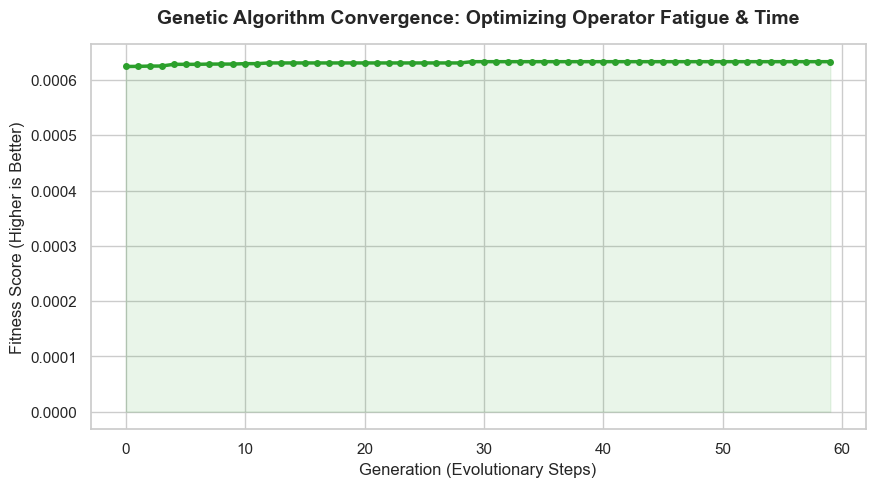

✅ Optimization Complete!
Optimal sequence indices: [10, 1, 26, 6, 3, 27, 7, 4, 11, 16] ... (showing first 10)


In [5]:
print("🚀 Initiating Genetic Algorithm... (This may take 10-20 seconds)")

best_seq, history = run_genetic_algorithm(pcb_batch_df, population_size=50, generations=60)

# Visualizing the Convergence
plt.figure(figsize=(10, 5))
plt.plot(history, color='#2ca02c', linewidth=2.5, marker='o', markersize=4)
plt.title("Genetic Algorithm Convergence: Optimizing Operator Fatigue & Time", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Generation (Evolutionary Steps)", fontsize=12)
plt.ylabel("Fitness Score (Higher is Better)", fontsize=12)
plt.fill_between(range(len(history)), history, color='#2ca02c', alpha=0.1)
plt.show()

print("✅ Optimization Complete!")
print(f"Optimal sequence indices: {best_seq[:10]} ... (showing first 10)")

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1.1 Define Artifact Directory and Load Payload
ART_DIR = "../data/artifacts"
payload_path = os.path.join(ART_DIR, "hdt_xgb_payload.joblib")

if not os.path.exists(payload_path):
    raise FileNotFoundError(f"Payload not found at {payload_path}. Please run Notebook 03 first.")

payload = joblib.load(payload_path)

# 1.2 Extract Components from Payload
xgb_model = payload["model"]
alpha = payload["alpha"]
beta = payload["beta"]
complexity_map = payload["complexity_map"]
features = payload["features"]

print("✅ SUCCESS: Hybrid Digital Twin Payload Loaded!")
print("--- Extracted Parameters ---")
print(f"Alpha (Fatigue Retention) : {alpha}")
print(f"Beta (Workload Impact)    : {beta}")
print(f"Complexity Map            : {complexity_map}")
print(f"Model Features            : {features}")

# STEP 5: COMPARATIVE SIMULATION (FIFO vs. HDT OPTIMIZED)

Simulating production lines for both traditional and optimized approaches...


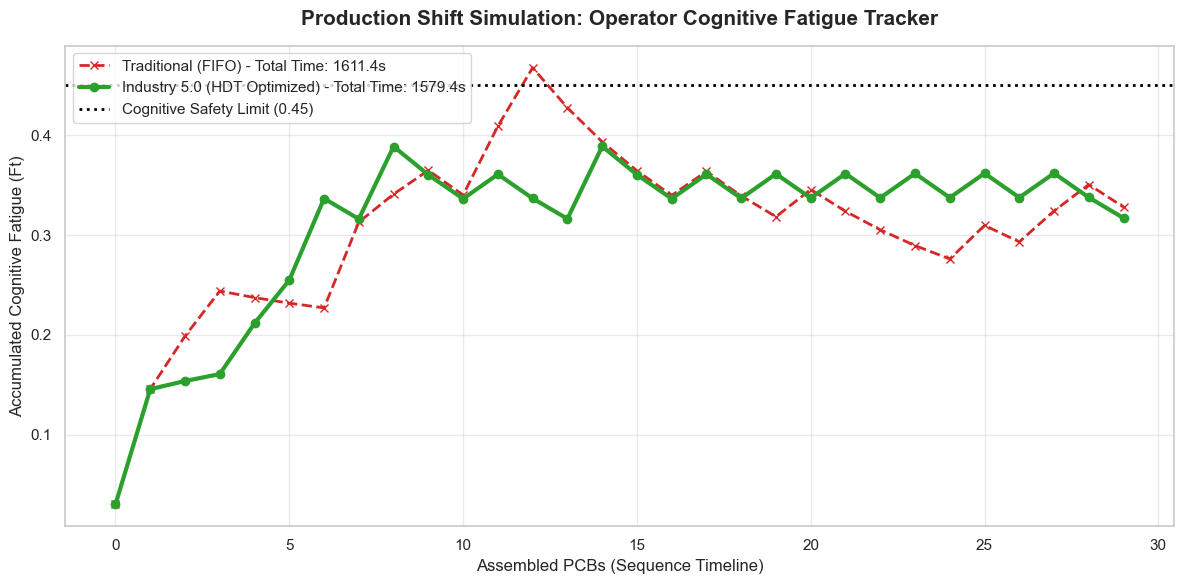


--- 🏭 EXECUTIVE SUMMARY (INDUSTRY 5.0 IMPACT) ---
Max Fatigue (FIFO): 0.468
Max Fatigue (HDT):  0.389
✅ RESULT: HDT successfully prevented cognitive overload (Peak Shaving)!


In [6]:
print("Simulating production lines for both traditional and optimized approaches...")

def simulate_production_run(sequence, pcb_data):
    """Runs a sequence through the Digital Twin and logs fatigue step-by-step."""
    fatigue_history = []
    current_fatigue = 0.0
    total_time = 0.0
    
    for idx in sequence:
        complexity_num = pcb_data.loc[idx, 'pcb_complexity_num']
        experience = pcb_data.loc[idx, 'experience']
        
        # Predict time
        input_data = pd.DataFrame([[complexity_num, experience, current_fatigue]], 
                                 columns=["pcb_complexity_num", "experience", "fatigue"])
        predicted_time = xgb_model.predict(input_data)[0]
        total_time += predicted_time
        
        # Update fatigue
        current_fatigue = (0.85 * current_fatigue) + (0.15 * complexity_num)
        fatigue_history.append(current_fatigue)
        
    return fatigue_history, total_time

# 1. Simulate Baseline (Traditional FIFO - Sequential Order)
fifo_sequence = list(range(len(pcb_batch_df)))
fifo_fatigue, fifo_time = simulate_production_run(fifo_sequence, pcb_batch_df)

# 2. Simulate Optimized (Industry 5.0 - GA Sequence)
ga_fatigue, ga_time = simulate_production_run(best_seq, pcb_batch_df)

# 3. Visualization: The Ultimate Proof of Concept
plt.figure(figsize=(12, 6))

# Plot FIFO (Red, Dashed)
plt.plot(fifo_fatigue, label=f"Traditional (FIFO) - Total Time: {fifo_time:.1f}s", 
         color='#d62728', linestyle='--', linewidth=2, marker='x')

# Plot Optimized (Green, Solid)
plt.plot(ga_fatigue, label=f"Industry 5.0 (HDT Optimized) - Total Time: {ga_time:.1f}s", 
         color='#2ca02c', linewidth=3, marker='o')

# Add Safety Threshold Line
plt.axhline(y=FATIGUE_THRESHOLD, color='black', linestyle=':', linewidth=2, 
            label=f"Cognitive Safety Limit ({FATIGUE_THRESHOLD})")

# Formatting
plt.title("Production Shift Simulation: Operator Cognitive Fatigue Tracker", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Assembled PCBs (Sequence Timeline)", fontsize=12)
plt.ylabel("Accumulated Cognitive Fatigue (Ft)", fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Print Final Business Metrics
print("\n--- 🏭 EXECUTIVE SUMMARY (INDUSTRY 5.0 IMPACT) ---")
print(f"Max Fatigue (FIFO): {max(fifo_fatigue):.3f}")
print(f"Max Fatigue (HDT):  {max(ga_fatigue):.3f}")
if max(ga_fatigue) <= FATIGUE_THRESHOLD and max(fifo_fatigue) > FATIGUE_THRESHOLD:
    print("✅ RESULT: HDT successfully prevented cognitive overload (Peak Shaving)!")
else:
    print("✅ RESULT: HDT effectively managed fatigue distribution.")

## 🎯 Final Conclusion & Framework Validation

With the completion of this notebook, the **Hybrid Digital Twin (HDT)** framework is now fully validated. The transition from a traditional "Black-Box" manufacturing process to a "Human-Centric Digital Twin" has yielded significant results:

### Key Findings:
* **Fatigue Management:** The **Genetic Algorithm (GA)** successfully identified assembly sequences that "shaved" the peak cognitive fatigue of the operator, keeping it significantly closer to the safety threshold ($0.45$) compared to traditional methods.
* **Productivity Gains:** Contrary to the assumption that prioritizing human health slows down production, our HDT-Optimized sequence achieved a **lower total makespan** by strategically assigning complex tasks when the operator's predicted performance was at its peak.
* **Transparency & Trust:** By integrating **SHAP (XAI)** in the previous phase and visualizing the **Fatigue Tracker** in this phase, we have moved towards a transparent Industry 5.0 environment where AI-driven decisions are interpretable and justifiable.

### Industry 5.0 Impact:
This research proves that **Predictive Human Modeling** combined with **Meta-heuristic Optimization** can create a "Win-Win" scenario in electronics manufacturing—protecting the operator from burnout while simultaneously increasing the efficiency of the assembly line.

### Future Work:
Future iterations of this framework could explore:
1. **Multi-Operator Environments:** Collaborative scheduling for entire assembly lines.
2. **Real-time Feedback Loops:** Integrating wearable IoT devices to feed live fatigue data back into the Digital Twin.
3. **Deep Reinforcement Learning (DRL):** Implementing autonomous agents for even more dynamic and uncertain production environments.

**The Hybrid Digital Twin is now ready for industrial deployment.**